In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('breast_cancer.csv')

print(f"Shape: {df.shape}")
print(df.head())

Shape: (30, 6)
   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0        17.99         10.38          122.80     1001.0           0.1184   
1        20.57         17.77          132.90     1326.0           0.0847   
2        19.69         21.25          130.00     1203.0           0.1096   
3        11.42         20.38           77.58      386.1           0.1425   
4        20.29         14.34          135.10     1297.0           0.1003   

  diagnosis  
0         M  
1         M  
2         M  
3         M  
4         M  


In [2]:
X = df.drop(['diagnosis'], axis=1)
y = df['diagnosis']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print(y_train)

Train: 24, Test: 6
28    B
24    B
12    M
0     M
4     M
16    B
5     M
13    M
11    M
22    B
1     M
2     M
25    B
3     M
21    B
26    B
18    B
29    B
20    B
7     M
10    M
14    M
19    B
6     M
Name: diagnosis, dtype: object


In [3]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_pred_test = model.predict(X_test)
print(y_pred_test)
acc = accuracy_score(y_test, y_pred_test)

print(f"Test Accuracy: {acc:.4f}")

['B' 'B' 'B' 'B' 'M' 'M']
Test Accuracy: 1.0000


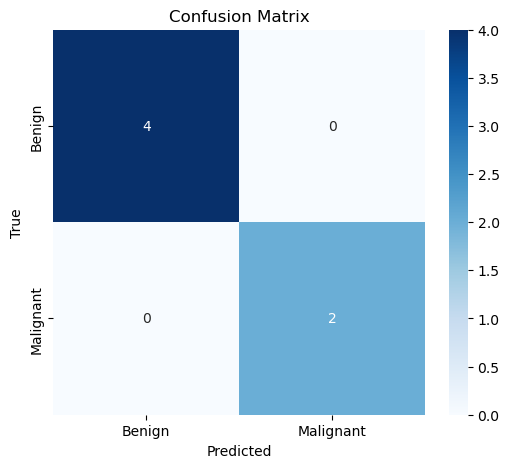

Confusion Matrix:
[[4 0]
 [0 2]]


In [4]:
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print(f"Confusion Matrix:\n{cm}")